# Proyek Capstone Coding Camp: Jurnal RuangRasa
- Nama: Dary Ihsan Amanullah
- Email: ihsandary2@gmail.com
- ID Dicoding: CDCC200D6Y2733

# Menentukan Pertanyaan Bisnis

1. Bagaimana distribusi proporsi emosi pengguna dalam data journaling, dan emosi apa yang paling dominan dalam 100 hari terakhir, serta bagaimana perubahannya untuk pemodelan?

2. Apakah terdapat perbedaan panjang teks (jumlah kata) antar kategori emosi, dan emosi mana yang cenderung menghasilkan curhatan lebih panjang?

3. Kata-kata apa yang paling sering muncul pada emosi (sadness, anger, fear, joy, neutral, love), dan tema apa yang paling dominan dalam curhatan pengguna?

# Import Semua Packages/Library

In [1]:
!pip install datasets Sastrawi wordcloud

In [2]:
# Library Olah Data
import pandas as pd
import numpy as np
import random
import uuid
from datetime import datetime, timedelta

# Library untuk mengambil data
from datasets import load_dataset
import requests
import io
from google.colab import drive
drive.mount('/content/drive')

# Library Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Library Text Cleaning
import re
import string
# from langdetect import detect
from collections import Counter
from tqdm.auto import tqdm
import html

# Library Balancing
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Setting grafik
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Semua package dasar berhasil dimuat!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Semua package dasar berhasil dimuat!


# Data Wrangling

## Gathering Data

In [3]:
print("Mengunduh Dataset 1 (Indonesian Public Opinion) via GitHub...")

# URL dasar ke dalam folder raw GitHub
base_url = "https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/"

# Daftar nama file sekaligus mapping label emosinya
file_info = {
    "AngerData.csv": "Anger",
    "FearData.csv": "Fear",
    "JoyData.csv": "Joy",
    "LoveData.csv": "Love",
    "NeutralData.csv": "Neutral",
    "SadData.csv": "Sadness"
}

dfs = []
for file, label in file_info.items():
    url = base_url + file
    try:
        temp_df = pd.read_csv(url, sep='\t')

        # Penyesuaian jumlah kolom
        if len(temp_df.columns) == 1:
            temp_df.columns = ['text_jurnal']
            temp_df['label_emosi'] = label
        elif len(temp_df.columns) >= 2:
            temp_df = temp_df.iloc[:, :2]
            temp_df.columns = ['text_jurnal', 'label_emosi']

        dfs.append(temp_df)
    except Exception as e:
        print(f"Gagal mengunduh {file}: {e}")

# Penggabungan lokal Dataset 1
if len(dfs) > 0:
    df1 = pd.concat(dfs, ignore_index=True)
    print(f"✓ Berhasil menggabungkan Dataset 1. Total: {len(df1)} baris.")
else:
    print("Gagal mengunduh Dataset 1. Cek koneksi internet atau URL GitHub.")

Mengunduh Dataset 1 (Indonesian Public Opinion) via GitHub...
✓ Berhasil menggabungkan Dataset 1. Total: 7080 baris.


In [4]:
print("Mengunduh Dataset 2 (Indonesian Twitter Emotion Dataset)...")

url_ds2 = "https://raw.githubusercontent.com/meisaputri21/Indonesian-Twitter-Emotion-Dataset/master/Twitter_Emotion_Dataset.csv"
download_ds2 = requests.get(url_ds2).content
df2 = pd.read_csv(io.StringIO(download_ds2.decode('utf-8')))

# Standardisasi nama kolom
df2 = df2.rename(columns={'tweet': 'text_jurnal', 'label': 'label_emosi'})

print(f"✓ Berhasil mengunduh Dataset 2. Total: {len(df2)} baris.")

Mengunduh Dataset 2 (Indonesian Twitter Emotion Dataset)...
✓ Berhasil mengunduh Dataset 2. Total: 4401 baris.


In [5]:
print("Menggabungkan Kedua Dataset...")
# Gabungkan df1 & df2
df_combined = pd.concat([df1, df2], ignore_index=True)

print(f"Total data gabungan mentah (2 Dataset): {len(df_combined)} baris")

Menggabungkan Kedua Dataset...
Total data gabungan mentah (2 Dataset): 11481 baris


In [6]:
print("Mengunduh Dataset Ekstra A (EmoTweetID Human)...")

try:
    # Membaca langsung dari file Colab
    # df_emotweet = pd.read_csv("EmoTweetID-Human.csv")

    # Membaca langsung dari drive
    path = "/content/drive/MyDrive/EmoTweetID-Human.csv"

    df_emotweet = pd.read_csv(path)

    if 'tweet' in df_emotweet.columns:
        df_emotweet = df_emotweet.rename(columns={'tweet': 'text_jurnal', 'label': 'label_emosi'})
    elif 'text' in df_emotweet.columns:
        df_emotweet = df_emotweet.rename(columns={'text': 'text_jurnal', 'label': 'label_emosi'})

    df_emotweet['label_emosi'] = df_emotweet['label_emosi'].str.lower()

    # Mengambil label dasar
    valid_labels = ['anger', 'fear', 'joy', 'sadness']
    df_emotweet = df_emotweet[df_emotweet['label_emosi'].isin(valid_labels)].copy()
    df_emotweet['label_emosi'] = df_emotweet['label_emosi'].str.capitalize()

    df_ekstra_a = df_emotweet[['text_jurnal', 'label_emosi']]
    print(f"✓ Sukses! +{len(df_ekstra_a)} data EmoTweetID ditambahkan.")
except FileNotFoundError:
    print("GAGAL: File 'EmoTweetID-Human.csv' belum di-upload ke Drive! Silakan upload dulu.")
except Exception as e:
    print(f"Gagal memproses EmoTweetID: {e}")

Mengunduh Dataset Ekstra A (EmoTweetID Human)...
✓ Sukses! +1602 data EmoTweetID ditambahkan.


In [7]:
print("Mengunduh Dataset Ekstra B (EmotCMT)...")

try:
    url_emotcmt = "https://raw.githubusercontent.com/ir-nlp-csui/emotcmt/main/codeswitch_emotion.csv"
    df_emotcmt = pd.read_csv(url_emotcmt)

    if 'tweet' in df_emotcmt.columns:
        df_emotcmt = df_emotcmt.rename(columns={'tweet': 'text_jurnal', 'label': 'label_emosi'})
    elif 'text' in df_emotcmt.columns:
         df_emotcmt = df_emotcmt.rename(columns={'text': 'text_jurnal', 'label': 'label_emosi'})

    map_emotcmt = {
        'marah': 'Anger', 'anger': 'Anger',
        'takut': 'Fear', 'fear': 'Fear',
        'senang': 'Joy', 'joy': 'Joy', 'happy': 'Joy',
        'sedih': 'Sadness', 'sadness': 'Sadness', 'sad': 'Sadness',
        'cinta': 'Love', 'love': 'Love'
    }
    df_emotcmt['label_emosi'] = df_emotcmt['label_emosi'].str.lower().map(map_emotcmt)
    df_emotcmt = df_emotcmt.dropna(subset=['label_emosi'])

    df_ekstra_b = df_emotcmt[['text_jurnal', 'label_emosi']]
    print(f"✓ Sukses! +{len(df_ekstra_b)} data EmotCMT ditambahkan.")
except Exception as e:
    print(f"Gagal mengunduh EmotCMT: {e}")

Mengunduh Dataset Ekstra B (EmotCMT)...
✓ Sukses! +582 data EmotCMT ditambahkan.


In [8]:
print("Menggabungkan Seluruh Dataset...")

kumpulan_df = [df1, df2]
if 'df_ekstra_a' in locals():
    kumpulan_df.append(df_ekstra_a)
if 'df_ekstra_b' in locals():
    kumpulan_df.append(df_ekstra_b)

df_combined = pd.concat(kumpulan_df, ignore_index=True)
print(f"Total data gabungan mentah: {len(df_combined)} baris!")

Menggabungkan Seluruh Dataset...
Total data gabungan mentah: 13665 baris!


In [9]:
print("Standardisasi Label Emosi...")
# Karena Dataset 1 dan 2 punya variasi penulisan label (sad vs sadness), harus disatukan

label_mapping = {
    'sad': 'Sadness',
    'sadness': 'Sadness',
    'anger': 'Anger',
    'fear': 'Fear',
    'joy': 'Joy',
    'happy': 'Joy',
    'love': 'Love',
    'neutral': 'Neutral'
}
# Pastikan semua teks kecil dulu baru di-map
df_combined['label_emosi'] = df_combined['label_emosi'].str.lower().map(label_mapping)

# Buang data yang labelnya kosong (jika ada error mapping)
df_combined = df_combined.dropna(subset=['label_emosi'])

print(f"Total data siap pakai setelah standardisasi: {len(df_combined)} baris.")

Standardisasi Label Emosi...
Total data siap pakai setelah standardisasi: 13665 baris.


**INFORMASI DATASET**

Dataset ini merupakan gabungan dari berbagai sumber (Indonesian Public Opinion, Twitter Emotion Dataset, EmoTweetID, dan EmotCMT) yang memuat opini dan cuitan publik. Penggabungan ini dilakukan untuk memperkaya variasi bahasa, termasuk penggunaan slang *code-mixed*, demi mengoptimalkan akurasi pengenalan sentimen dari pengguna.

---


**Fitur Utama**

*   `text_jurnal`: Berisi kalimat, cuitan, atau dokumen teks dalam bahasa Indonesia. Ini adalah fitur input utama yang memuat tulisan dari pengguna beserta konteks bahasanya.
*   `label_emosi`: Kategori kelas emosi dasar (seperti Anger, Fear, Joy, Love, Neutral, dan Sadness). Fitur ini bertindak sebagai target prediksi (kelas).




**Memuat Tabel Gabungan**

In [10]:
df_combined

,text_jurnal,label_emosi
0,pagi2 udah di buat emosi :),Anger
1,"kok stabilitas negara, memange 10 thn negara t...",Anger
2,dah lah emosi mulu liat emyu,Anger
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",Anger
4,dih lu yg nyebelin bego,Anger
...,...,...
13660,[USERNAME] tapi tugasku on going semua yang se...,Sadness
13661,"Bener aja doong, rata-rata yang naik MRT emang...",Joy
13662,We're gonna be okey. Sini pelukkk,Sadness
13663,[USERNAME] Hbd buat mamah qamuuh semoga makin ...,Joy


**Insight:**

Tabel gabungan kini telah memiliki komposisi `text_jurnal` dan `label_emosi` yang terstandarisasi dengan 6 jenis kategori emosi utama yang seragam.
Terdapat 6 jenis `label`, yaitu Anger, Fear, Joy, Love, Neutral, dan Sadness.


**Simulasi Metadata RuangRasa (Menambahkan journal_id, user_id, timestamp, & label_encoded)**

In [11]:
print("Menambahkan metadata simulasi...")

df = df_combined.copy()

# Menambahkan identifier unik
df['journal_id'] = [str(uuid.uuid4())[:8] for _ in range(len(df))]
df['user_id'] = [random.randint(1, 1000) for _ in range(len(df))]

# Menambahkan timestamp acak selama 100 hari terakhir
end_date = datetime.now()
start_date = end_date - timedelta(days=100)

def random_date(start, end):
    delta = end - start
    random_days = random.randrange(delta.days)
    random_seconds = random.randrange(24*60*60)
    return start + timedelta(days=random_days, seconds=random_seconds)

df['timestamp'] = [random_date(start_date, end_date) for _ in range(len(df))]
print("✓ Metadata ID dan Timestamp berhasil dibuat.")

Menambahkan metadata simulasi...
✓ Metadata ID dan Timestamp berhasil dibuat.


In [12]:
# Encoding Label Emosi (untuk model AI)
unique_labels = df['label_emosi'].unique()
label_encoder_dict = {label: idx for idx, label in enumerate(unique_labels)}
df['label_encoded'] = df['label_emosi'].map(label_encoder_dict)

# Menyusun ulang urutan posisi kolom agar elegan
df = df[['journal_id', 'user_id', 'text_jurnal', 'timestamp', 'label_emosi', 'label_encoded']]
df = df.sort_values(by='timestamp').reset_index(drop=True)

print("✓ Kolom berhasil disusun ulang.")

✓ Kolom berhasil disusun ulang.


In [13]:
display(df.head())

print("\nDistribusi Emosi Awal:")
print(df['label_emosi'].value_counts())

,journal_id,user_id,text_jurnal,timestamp,label_emosi,label_encoded
0,4edace48,1,"iya, mau kelarin! suka banget sama adaptasinya...",2026-02-08 03:56:37.068236,Love,3
1,760264e1,831,gatauu lg sedih kalo liat foto2 cogan,2026-02-08 04:09:28.068236,Sadness,5
2,ece82cd6,623,"kita mungkin sekarang merasa takut, tapi nanti...",2026-02-08 04:09:36.068236,Joy,2
3,a2a3d3ae,546,Bisa mencium bau tanah kering yang abis kesira...,2026-02-08 04:29:14.068236,Joy,2
4,759bdfd0,528,itu knp gue benci bgt. mrk yg enak kita yg sen...,2026-02-08 04:38:42.068236,Anger,0



Distribusi Emosi Awal:
label_emosi
Joy        2904
Anger      2898
Sadness    2406
Fear       2023
Neutral    2001
Love       1433
Name: count, dtype: int64


In [14]:
df.to_csv('dataset_ruangrasa_jurnal_ai_awal.csv', index=False)

### Profil Dataset Awal

Tabel ini menjelaskan setiap fitur (kolom) yang terdapat pada dataset awal sebelum proses pembersihan data (Data Cleaning) dan feature engineering. Dataset ini siap digunakan untuk pemodelan sentimen emosi.

| Nama Kolom | Tipe Data | Kategori | Deskripsi |
| :--- | :--- | :--- | :--- |
| `journal_id` | String / Object | Identifier | Kode unik untuk mengidentifikasi setiap entri jurnal atau teks curhatan. |
| `user_id` | Integer | Identifier | Nomor unik pengguna yang menulis jurnal tersebut. |
| `text_jurnal` | String / Object | Fitur Utama | Teks curhatan yang belum melalui tahap *preprocessing* (seperti *case folding*, penghapusan tanda baca, dan *stopword* removal). |
| `timestamp` | Datetime | Waktu | Waktu dan tanggal saat jurnal atau curhatan tersebut direkam. |
| `label_emosi` | String / Object | Target | Label apakah teks mengandung emosi marah, senang, takut, sayang, netral, atau sedih (6 kelas). |
| `label_encoded` | Integer | Target | Label emosi dalam bentuk angka (0-5).|

## Assessing Data

Setelah data berhasil dikumpulkan, langkah selanjutnya adalah melakukan penilaian (assessing) untuk mengidentifikasi masalah kualitas dalam dataset. Pemeriksaan ini mencakup:

1. **Pemeriksaan Tipe Data**. Perlu dipastikan bahwa setiap kolom memiliki tipe data yang sesuai.
2.  **Pemeriksaan Missing Values**. Mengecek keberadaan nilai yang hilang. Hal ini agar nilai kosong tidak merusak hasil analisis dan performa model.  
3. **Pemeriksaan Data Duplikat**. Mendeteksi duplikasi. Pertama, melihat duplikasi baris secara keseluruhan. Kedua, melacak apakah ada teks curhatan yang diinput berulang kali.  
4. **Ringkasan Parameter Statistik**. Mendeteksi anomali atau melihat distribusi umum. Selain itu, memeriksa proporsi kelas data dengan untuk mengetahui seberapa banyak entri pada masing-masing kategori emosi.  

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13665 entries, 0 to 13664
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   journal_id     13665 non-null  object        
 1   user_id        13665 non-null  int64         
 2   text_jurnal    13665 non-null  object        
 3   timestamp      13665 non-null  datetime64[ns]
 4   label_emosi    13665 non-null  object        
 5   label_encoded  13665 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 640.7+ KB


**Insight:**

Tabel text memiliki lima kolom yang tipe datanya sudah sesuai. Dengan total entri 13.665, semua kolom juga memiliki jumlah yang selaras.

Komposisi tipe data terdiri dari `datetime64` (1 kolom), `int64` (2 kolom), `object` (3 kolom).

In [16]:
df.isna().sum()

,0
journal_id,0
user_id,0
text_jurnal,0
timestamp,0
label_emosi,0
label_encoded,0


**Insight:**

Dengan `df.isna().sum()` dipastikan tidak ada kolom yang memiliki missing value.

In [17]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada duplikasi baris secara keseluruhan (`duplicated() = 0`), menandakan tidak ada anomali data duplikat pada tabel text.

In [18]:
print("Jumlah duplikasi kolom text_jurnal: ", df.duplicated(subset=['text_jurnal']).sum())

Jumlah duplikasi kolom text_jurnal:  105


**Insight:**

Terdapat duplikasi baris secara spesifik (`duplicated(subset=['text_jurnal']) = 105`), menandakan ada teks curhatan yang diinput berulang kali.

In [19]:
df.describe()

,user_id,timestamp,label_encoded
count,13665.000000,13665,13665.000000
mean,502.943066,2026-03-29 23:43:13.041598720,2.353750
min,1.000000,2026-02-08 03:56:37.068236,0.000000
25%,256.000000,2026-03-05 11:53:04.068236032,1.000000
50%,503.000000,2026-03-29 18:11:17.068236032,2.000000
75%,753.000000,2026-04-23 16:29:41.068236032,4.000000
max,1000.000000,2026-05-19 03:34:05.068236,5.000000
std,289.498844,NaN,1.773883


**Insight:**

Perintah `df.describe()` digunakan untuk ringkasan metrik numerik.

In [20]:
df.describe(include='object')

,journal_id,text_jurnal,label_emosi
count,13665,13665,13665
unique,13665,13560,6
top,690b4241,sedih,Joy
freq,1,5,2904


**Insight:**

Sementara `df.describe(include='object')` digunakan untuk melihat ringkasan statistik dari tipe data teks/kategorikal.

Terlihat bahwa dari 13.665 entri data, terdapat 13.560 data text yang unik, mengindikasikan bahwa sekitar 105 text merupakan duplikat.

In [21]:
display(df['label_emosi'].value_counts())

,count
label_emosi,
Joy,2904
Anger,2898
Sadness,2406
Fear,2023
Neutral,2001
Love,1433


**Insight:**

Memeriksa proporsi kelas data dengan `df['label_emosi'].value_counts()` untuk mengetahui seberapa banyak entri pada masing-masing kategori emosi.

Terlihat bahwa label joy memiliki entri terbanyak yaitu 2.904 dan label love paling sedikit yaitu 1.433.

## Cleaning Data

Setelah mengidentifikasi berbagai masalah pada tahap Assessing Data (seperti kontaminasi noise, teks opini publik, dan ketidakseimbangan kelas), selanjutnya dilakukan pembersihan (Cleaning Data). Proses ini menggunakan pendekatan Soft Preprocessing untuk memastikan teks tidak hanya bersih, tetapi struktur semantiknya tetap utuh agar siap dianalisis dan dimasukkan ke dalam model Deep Learning (BiLSTM).


---


**Menghapus Data Duplikat**

Ditemukan adanya duplikasi spesifik pada kolom teks jurnal. Akan dilakukan penghapusan duplikat berdasarkan kolom `text_jurnal` untuk memastikan setiap baris data benar-benar unik, sehingga tidak menyebabkan bias repetitif pada model.

**Membersihkan Teks (Text Preprocessing)**

Karena data berbentuk teks Twitter yang akan digunakan untuk deteksi emosi, perlu dilakukan standardisasi dengan sangat hati-hati agar makna kalimat tidak rusak:

- Pembersihan Karakter dan Simbol
  
  Melakukan case folding (mengubah ke huruf kecil), serta menghapus tautan URL, mention akun (@), hashtag (#), token literal [username], dan angka.  
- Normalisasi Teks & Huruf Berulang
  
  Mengganti tanda baca dengan spasi, membuang semua karakter selain alfabet (a-z), serta menormalkan huruf berulang yang berlebihan (misalnya "horeeee" menjadi "horee") agar tidak membingungkan model.  
- Normalisasi Bahasa Gaul (Slang)
  
  Memperbaiki singkatan dan slang tidak baku (seperti "yg", "bgt", "wkwk") menjadi bahasa Indonesia standar menggunakan kamus translasi kustom (slang dictionary).
(Catatan: Proses penghapusan Stopwords sengaja tidak dilakukan agar model AI dapat mempelajari struktur sintaksis kalimat secara utuh, seperti memahami fungsi kata negasi "tidak" atau "bukan").

**Pembersihan Darurat (Emergency Purge)**

Data publik sangat rentan terhadap noise yang tidak relevan dengan konteks kesehatan mental. Oleh karena itu, dilakukan pembersihan lanjutan:
- Penghapusan Teks Toxic & Berita
  
  Mengeliminasi baris yang mengandung kata-kata kasar (hate speech), iklan, hingga komentar politik atau berita publik menggunakan daftar hitam kata kunci (blacklist keywords).  
- Penanganan Code-Switching
  
  Membuang teks yang terlalu banyak menggunakan percampuran bahasa Inggris (lebih dari 2 kata hubung Inggris) karena model ditargetkan untuk Bahasa Indonesia.
- Koreksi Label (Label Mismatch)

  Menghapus teks yang mengandung kata "nangis" atau "sedih" namun berada pada label Joy, untuk mencegah kebingungan algoritma (label noise).

**Filtering Point-of-View (POV) Jurnaling**

Karena dataset berasal dari opini publik, banyak teks yang bukan merupakan curhatan pribadi. Untuk menyimulasikan data journaling yang sesungguhnya, diterapkan filter Point-of-View (POV) yang sangat ketat.
- Penyaringan Subjek Personal

  Hanya mempertahankan baris data yang mengandung kata ganti orang pertama (aku, saya, gue, gw, diriku, ku, kami, kita). Langkah ini memastikan bahwa teks yang dilatih ke model benar-benar bersifat introspektif dan reflektif.

**Menghapus Data Duplikat & Merapikan Kolom**

Setelah teks dibersihkan, dilakukan penghapusan duplikat berdasarkan kolom text_clean (teks yang sudah bersih). Hal ini penting karena gabungan dari beberapa sumber dataset sering kali memuat cuitan yang sama namun dilabeli berbeda oleh anotator yang berbeda. Terakhir, menghapus kolom-kolom bantuan (seperti word_count) untuk merapikan struktur data.

**Penanganan Ketidakseimbangan Kelas (Global Class Weights)**

Distribusi data antar label emosi secara natural tidak seimbang (misalnya Joy dan Anger mendominasi dibandingkan Love dan Fear). Daripada melakukan pemotongan data (downsampling) yang akan membuang banyak informasi berharga, strategi yang digunakan adalah mengekstraksi Global Class Weights. Bobot matematis ini akan diserahkan kepada tim AI untuk disematkan pada parameter pelatihan model, sehingga algoritma akan memberikan "perhatian ekstra" saat mempelajari kelas emosi yang minoritas.

**Menghapus Data Duplikat**

In [22]:
print("Jumlah data sebelum dihapus duplikat:", len(df))

df = df.drop_duplicates(subset=['text_jurnal']).reset_index(drop=True)

print("Jumlah data setelah dihapus duplikat:", len(df))
print("Jumlah duplikasi kolom text_jurnal: ", df.duplicated(subset=['text_jurnal']).sum())

Jumlah data sebelum dihapus duplikat: 13665
Jumlah data setelah dihapus duplikat: 13560
Jumlah duplikasi kolom text_jurnal:  0


**Insight:**

Menghapus sebanyak 105 entri data yang mengalami duplikat pada kolom `text_jurnal`.

**Data Cleaning & Text Preprocessing**

Kamus Bahasa Gaul (Slang)

In [23]:
# Kamus translasi bahasa gaul (Slang)
slang_dict = {
    # Negasi
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "ngga": "tidak", "tak": "tidak",
    "gk": "tidak", "kgk": "tidak", "kagak": "tidak", "engga": "tidak",
    "nda": "tidak",

    # Waktu / status
    "udah": "sudah", "udh": "sudah", "sdh": "sudah", "dah": "sudah", "dh": "sudah", "da": "sudah",
    "blm": "belum", "blom": "belum", "belom": "belum",

    # Kata umum
    "yg": "yang", "yng": "yang",
    "dgn": "dengan", "dg": "dengan",
    "sm": "sama",
    "utk": "untuk", "buat": "untuk", "tuk": "untuk",
    "krn": "karena", "karna": "karena", "soalnya": "karena",

    # Intensitas
    "bgt": "banget", "bngt": "banget", "bgtt": "banget", "bat": "banget",

    # Perasaan / opini
    "mantap": "keren", "mantul": "keren", "gacor": "keren",
    "seru": "menyenangkan", "asik": "menyenangkan",
    "jelek": "buruk", "payah": "buruk", "parah": "buruk",

    # Perbandingan
    "kyk": "seperti", "kayak": "seperti", "kek": "seperti",

    # Keinginan
    "pgn": "ingin", "pengen": "ingin",

    # Partikel
    "aja": "saja", "doang": "saja", "thok": "saja", "tok": "saja",
    "jg": "juga",
    "tp": "tapi", "tpi": "tapi",

    # Penegasan
    "emg": "memang", "emang": "memang",

    # Tanya
    "knp": "kenapa", "ngapa": "kenapa", "napa": "kenapa", "nape": "kenapa",
    "gimana": "bagaimana", "gmn": "bagaimana", "kek mana": "bagaimana",

    # Waktu sekarang
    "skrg": "sekarang", "skrang": "sekarang",

    # Keharusan
    "hrs": "harus", "kudu": "harus", "musti": "harus", "mesti": "harus",

    # Orang
    "gw": "saya", "gue": "saya", "gua": "saya",
    "lu": "kamu", "lo": "kamu", "loe": "kamu", "u": "kamu",

    # Chat slang
    "pls": "tolong", "plis": "tolong",
    "thx": "terima kasih", "makasih": "terima kasih", "mksh": "terima kasih",

    # Emosi ekspresif (hapus noise)
    "wkwk": "", "wkwkwk": "", "wkwkww": "", "wkwkwkwk": "", "wk": "", "haha": "", "hehe": "", "hihi": "",
    "lol": "", "xixi": "", "kwkw": "",

    # Tambahan
    "cape": "capek", "capek": "lelah",
    "bt": "bosan", "bete": "bosan",
    "drun": "kadrun",
    "kesel": "marah",
    "seneng": "senang",
    "nangis": "menangis",
}

Soft Preprocessing (Regex dan Normalisasi)

In [24]:
print("Memulai Soft Preprocessing (Cleaning & Normalisasi Slang)...")

def soft_clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Decode HTML entities (misal: &amp; menjadi &)
    text = html.unescape(text)

    # Hapus URL, Mention, dan Hashtag (opsional, tapi disarankan untuk Twitter)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus URL
    text = re.sub(r'\@\w+|\#', '', text) # Hapus mention dan hashtag

    # Hapus token literal 'url'
    text = re.sub(r'\burl\b', '', text)

    # Hapus kata 'username' dan '[username]'
    text = re.sub(r'\[?username\]?', '', text)

    # Hapus marker spesifik [URL], [USERNAME], [SENSITIVE...] tanpa case-sensitive
    text = re.sub(r'\[url\]|\[username\]|\[sensitive[^\]]*\]', ' ', text, flags=re.IGNORECASE)

    # Hapus angka (biasanya tidak relevan untuk emosi)
    text = re.sub(r'\d+', '', text)

    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Ganti tanda baca dengan spasi (agar kata tidak menempel)
    text = re.sub(r'[^\w\s]', ' ', text)

    # Hapus spasi di awal dan akhir
    text = text.strip()

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # Normalisasi huruf (membuang selain a-z dan huruf berulang berlebihan)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # Normalisasi Slang menggunakan slang_dict
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]

    return ' '.join(normalized_words)

tqdm.pandas(desc="Cleaning Text")

df['text_clean'] = df['text_jurnal'].progress_apply(soft_clean_text)

print("\nPembersihan Teks Selesai!")
display(df[['label_emosi', 'text_jurnal', 'text_clean']].sample(5, random_state=42))

print(f"Jumlah data sebelum pembersihan lanjutan: {len(df)}")

Memulai Soft Preprocessing (Cleaning & Normalisasi Slang)...


Cleaning Text:   0%|          | 0/13560 [00:00<?, ?it/s]


Pembersihan Teks Selesai!


,label_emosi,text_jurnal,text_clean
5556,Anger,Ya bayangin lah kamu punya bias dikatain plast...,ya bayangin lah kamu punya bias dikatain plast...
10383,Neutral,"salah bagi orang yang pikirannya negatif mulu,...",salah bagi orang yang pikirannya negatif mulu ...
12986,Anger,bodoh banget dah checkout maybelline lupa pili...,bodoh banget sudah checkout maybelline lupa pi...
12270,Fear,gue ngeri itu orang kecebur menk,saya ngeri itu orang kecebur menk
533,Joy,[USERNAME] Selamat Siang Sahabat Pos. Kiriman ...,selamat siang sahabat pos kiriman tsb sudah di...


Jumlah data sebelum pembersihan lanjutan: 13560


**Data Constraint & Filtering**

Pemfilteran Topik (Blacklist Sensitif & Iklan)

In [25]:
# Daftar Hitam (Blacklist) Keyword Toxic, Politik, dan Iklan
toxic_keywords = [
    'bego', 'bangsat', 'anjg', 'anjing', 'anjir', 'anjr','goblok', 'tolol', 'jancok', 'bajingan', 'kontol',
    'brengsek', 'mesum', 'jokowi', 'prabowo', 'hti', 'fpi', 'cebong', 'kadrun', 'anies', 'ganjar',
    'avail', 'open bo', 'vcs', 'promo', 'murah', 'diskon', 'shopee', 'tokopedia',
    'presiden', 'nkri', 'pemerintah', 'menteri', 'polisi', 'kasus', 'netizen', 'viral', 'system',
    'ketegasan pak', 'kebakaran hutan', 'game hentai', 'public transit',
    'psycho', 'fds', 'porn', 'brengsek'
]

# Membuat pola regex untuk mencari kata-kata toxic sebagai kata utuh (bukan bagian dari kata lain)
pattern = '|'.join([r'\b{}\b'.format(re.escape(w)) for w in toxic_keywords])

# Membuang baris yang mengandung keyword di atas
df = df[~df['text_clean'].str.contains(pattern, case=False, na=False)]
print(f"Sisa data setelah hapus keyword toxic/politik/iklan: {len(df)}")


Sisa data setelah hapus keyword toxic/politik/iklan: 12565


**Insight:**

Menghapus sebanyak 995 entri data yang mengandung kata-kata di blacklist pada kolom `text_jurnal`.

Validasi Konteks Curhatan (POV & Syarat Panjang Kata)

In [26]:
# Filter Panjang Teks
df['word_count'] = df['text_clean'].str.split().str.len()

# Deteksi kata ganti orang pertama
first_person = ['aku', 'saya', 'gue', 'gw', 'diriku', 'ku', 'kami', 'kita']
pattern_fpp = '|'.join([r'\b{}\b'.format(w) for w in first_person])
df['is_personal'] = df['text_clean'].str.contains(pattern_fpp, case=False, na=False)

# Hapus label Neutral yang panjangnya 8 kata atau kurang
df = df[~((df['label_emosi'] == 'Neutral') & (df['word_count'] <= 8))]

# Logika Filter:
# Simpan JIKA ada kata ganti orang pertama & panjang kata > 3
# ATAU tidak ada kata ganti, TAPI panjang kata > 7 agar konteks jelas
df = df[((df['is_personal'] == True) & (df['word_count'] > 3)) | ((df['is_personal'] == False) & (df['word_count'] > 7))]

# Bersihkan kolom bantuan
df = df.drop(columns=['word_count', 'is_personal']).reset_index(drop=True)

# Kalimat di bawah 20 huruf biasanya tidak memiliki konteks emosi yang cukup.
df = df[df['text_clean'].str.len() >= 20]

print(f"Sisa data final setelah filter POV dan teks pendek: {len(df)}")

# Cek Ulang Distribusi
print("\nDistribusi Kelas:")
print(df['label_emosi'].value_counts())

Sisa data final setelah filter POV dan teks pendek: 10230

Distribusi Kelas:
label_emosi
Joy        2142
Anger      2005
Sadness    1956
Fear       1485
Neutral    1347
Love       1295
Name: count, dtype: int64


**Insight:**

Menghapus sebanyak 2.335 entri data yang tidak memiliki konteks jelas pada kolom `text_jurnal`.

In [27]:
print(f"Banyak Entri Data: {len(df)}")
print(df)

Banyak Entri Data: 10230
      journal_id  user_id                                        text_jurnal  \
0       4edace48        1  iya, mau kelarin! suka banget sama adaptasinya...   
1       ece82cd6      623  kita mungkin sekarang merasa takut, tapi nanti...   
2       a2a3d3ae      546  Bisa mencium bau tanah kering yang abis kesira...   
3       759bdfd0      528  itu knp gue benci bgt. mrk yg enak kita yg sen...   
4       282777d4      249  having faith is a bless. pas lagi sedih atau d...   
...          ...      ...                                                ...   
10233   0fb248eb      821  [USERNAME] Aku ingat, ketika kita masih saling...   
10234   0b2278a9      172  ihh sama punya ku juga udh 2 hari masa tertund...   
10235   7a636a65       94   chara saya fleksibel sebenernya, kalau lagi c...   
10236   cdc716c2      299  Berkumpul dengan temen-temen SMP, yes SMP. Yg ...   
10237   fb314bc5      753  Satu lagi, pilihan 'menikah' tidak ada didafta...   

              

**Insight:**

Hasil pembersihan data duplikat, regex & normalisasi, dan pemfilteran.

**Penanganan Anomali & Isu Spesifik**

Label Mismatch

In [28]:
# Contoh : Menangis bahagia yang dilabeli Joy
# Model akan bingung jika kata "nangis/sedih" ada di dalam kelas Joy. Hapus agar tidak noise.
mismatch_words = ['nangis', 'menangis', 'sedih', 'air mata']
pattern_mismatch = '|'.join([r'\b{}\b'.format(re.escape(w)) for w in mismatch_words])

df = df[~((df['label_emosi'] == 'Joy') & (df['text_clean'].str.contains(pattern_mismatch, case=False, na=False)))]

print(f"Sisa data setelah penanganan label mismatch: {len(df)}")

Sisa data setelah penanganan label mismatch: 10155


Relabeled / Inkonsistensi Duplikat

In [29]:
# Karena menggabungkan beberapa sumber, ada kalimat sama yang dilabeli beda oleh annotator berbeda.
# Buang duplikat berdasarkan teksnya saja, lalu ambil yang pertama kali muncul.
df = df.drop_duplicates(subset=['text_clean'], keep='first')

print(f"Sisa data setelah penanganan duplikasi labelling: {len(df)}")

Sisa data setelah penanganan duplikasi labelling: 10129


Code-Switching Berat (Bahasa Inggris)

In [30]:
# Deteksi heuristik sederhana: Jika ada lebih dari 2 kata stopword Inggris, anggap code-switching
english_stopwords = [' i ', ' you ', ' my ', ' the ', ' and ', ' with ', ' all ', ' talking ', ' friends ', ' perfect ']

df['english_count'] = df['text_clean'].apply(lambda x: sum(1 for w in english_stopwords if w in f" {x} "))

df = df[df['english_count'] <= 2]
df = df.drop(columns=['english_count'])

print(f"Sisa data setelah penanganan code-switching (bahasa Inggris): {len(df)}")

Sisa data setelah penanganan code-switching (bahasa Inggris): 10066


Cleaning Label Noise Kelas 'Neutral'

In [31]:
# Membuang entri Neutral yang mengandung kata emosi meledak-ledak
strong_emotion_words = [
    'sedih', 'menangis', 'nangis', 'marah', 'benci', 'kesal',
    'takut', 'cinta', 'sayang', 'bahagia', 'kecewa', 'hancur'
]
pattern_strong = '|'.join([r'\b{}\b'.format(w) for w in strong_emotion_words])

# Hapus JIKA kelasnya Neutral DAN mengandung kata emosi kuat
df = df[~((df['label_emosi'] == 'Neutral') & (df['text_clean'].str.contains(pattern_strong, case=False, na=False)))]

print(f"Sisa data setelah penanganan emosi meledak di kelas Neutral: {len(df)}")

Sisa data setelah penanganan emosi meledak di kelas Neutral: 9700


In [32]:
# Finalisasi

print(f"\nSisa data final: {len(df)}")
print("\nDistribusi Kelas Final (Siap Training):")
print(df['label_emosi'].value_counts())


Sisa data final: 9700

Distribusi Kelas Final (Siap Training):
label_emosi
Joy        2044
Anger      1994
Sadness    1943
Fear       1471
Love       1275
Neutral     973
Name: count, dtype: int64


**Insight:**

Data final setelah berbagai proses adalah 9.700.

**Mengurutkan Kolom**

In [33]:
df = df[['journal_id', 'user_id', 'text_jurnal', 'text_clean', 'timestamp', 'label_emosi', 'label_encoded']]

In [34]:
df

,journal_id,user_id,text_jurnal,text_clean,timestamp,label_emosi,label_encoded
0,4edace48,1,"iya, mau kelarin! suka banget sama adaptasinya...",iya mau kelarin suka banget sama adaptasinya k...,2026-02-08 03:56:37.068236,Love,3
1,ece82cd6,623,"kita mungkin sekarang merasa takut, tapi nanti...",kita mungkin sekarang merasa takut tapi nanti ...,2026-02-08 04:09:36.068236,Joy,2
2,a2a3d3ae,546,Bisa mencium bau tanah kering yang abis kesira...,bisa mencium bau tanah kering yang abis kesira...,2026-02-08 04:29:14.068236,Joy,2
3,759bdfd0,528,itu knp gue benci bgt. mrk yg enak kita yg sen...,itu kenapa saya benci banget mrk yang enak kit...,2026-02-08 04:38:42.068236,Anger,0
5,cdb3a41a,897,dulu gue pernah diajarin buat cari tau apa yan...,dulu saya pernah diajarin untuk cari tau apa y...,2026-02-08 04:55:01.068236,Neutral,4
...,...,...,...,...,...,...,...
10233,0fb248eb,821,"[USERNAME] Aku ingat, ketika kita masih saling...",aku ingat ketika kita masih saling bercanda te...,2026-05-19 02:14:31.068236,Sadness,5
10234,0b2278a9,172,ihh sama punya ku juga udh 2 hari masa tertund...,ihh sama punya ku juga sudah hari masa tertund...,2026-05-19 02:41:22.068236,Anger,0
10235,7a636a65,94,"chara saya fleksibel sebenernya, kalau lagi c...",chara saya fleksibel sebenernya kalau lagi cao...,2026-05-19 02:58:33.068236,Joy,2
10236,cdc716c2,299,"Berkumpul dengan temen-temen SMP, yes SMP. Yg ...",berkumpul dengan tementemen smp yes smp yang p...,2026-05-19 03:05:11.068236,Sadness,5


**Insight:**

Mengurutkan ulang kolom.

**Memberikan Class Weight karena Imbalance Data**

In [35]:
print("Distribusi label:")
print(df['label_emosi'].value_counts())
print(f"\nTotal: {len(df)} entries")

print("Menghitung Global Class Weights (Referensi untuk Tim AI)...")

# Membuat mapping angka kembali ke teks label
emotion_labels_map = {idx: label for label, idx in label_encoder_dict.items()}

# Menghitung bobot penyeimbang berdasarkan SELURUH data
y_all = df['label_encoded'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_all), y=y_all)

# Memasukkan bobot ke dalam dictionary
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Menampilkan hasil
for num, label in emotion_labels_map.items():
    print(f"{num}: {label} -> Bobot: {class_weight_dict[num]:.4f}")

print(f"\n[INFO UNTUK TIM AI] Dictionary Bobot Global: {class_weight_dict}\n")

Distribusi label:
label_emosi
Joy        2044
Anger      1994
Sadness    1943
Fear       1471
Love       1275
Neutral     973
Name: count, dtype: int64

Total: 9700 entries
Menghitung Global Class Weights (Referensi untuk Tim AI)...
0: Anger -> Bobot: 0.8108
1: Fear -> Bobot: 1.0990
2: Joy -> Bobot: 0.7909
3: Love -> Bobot: 1.2680
4: Neutral -> Bobot: 1.6615
5: Sadness -> Bobot: 0.8320

[INFO UNTUK TIM AI] Dictionary Bobot Global: {0: np.float64(0.8107656302240054), 1: np.float64(1.0990256061636074), 2: np.float64(0.7909328114807567), 3: np.float64(1.2679738562091503), 4: np.float64(1.6615279205207263), 5: np.float64(0.8320466632355464)}



**Insight:**

Memberikan class weight label agar model klasifikasi nantinya tidak condong memprediksi kelas mayoritas.

# Exploratory Data Analysis

Tujuan utama dari tahap ini adalah untuk memahami distribusi data dan mencari wawasan (insights) awal yang dapat menjawab pertanyaan bisnis.

In [36]:
df.describe(include="object")

,journal_id,text_jurnal,text_clean,label_emosi
count,9700,9700,9700,9700
unique,9700,9700,9700,6
top,fb314bc5,"Satu lagi, pilihan 'menikah' tidak ada didafta...",satu lagi pilihan menikah tidak ada didaftar p...,Joy
freq,1,1,1,2044


In [37]:
df.describe()

,user_id,timestamp,label_encoded
count,9700.00000,9700,9700.000000
mean,503.39866,2026-03-30 00:09:14.780091648,2.370206
min,1.00000,2026-02-08 03:56:37.068236,0.000000
25%,258.00000,2026-03-05 08:55:08.568236032,1.000000
50%,503.50000,2026-03-29 20:45:54.068236032,2.000000
75%,753.00000,2026-04-23 22:00:10.068236032,4.000000
max,1000.00000,2026-05-19 03:24:27.068236,5.000000
std,289.23444,NaN,1.781195


In [38]:
df_eda = df.copy()
# Hitung jumlah kata
df_eda['jumlah_kata'] = df_eda['text_clean'].apply(lambda x: len(str(x).split()))

# Simpan angka original data
original_data_len = 13665

print("[DATA QUALITY ASSESSMENT]")
print(f"Original data: {original_data_len} entries")
print(f"Final data: {len(df_eda)} entries")
# Perbaikan rumus retensi data
print(f"Data retention: {(len(df_eda)/original_data_len)*100:.1f}%")
print(f"Avg text length: {df_eda['jumlah_kata'].mean():.0f} words")
print(f"Unique users represented: {df_eda['user_id'].nunique()}")

[DATA QUALITY ASSESSMENT]
Original data: 13665 entries
Final data: 9700 entries
Data retention: 71.0%
Avg text length: 24 words
Unique users represented: 1000


**Insight:**

- Setelah melewati serangkaian proses cleaning yang sangat ketat (penghapusan duplikat, penyaringan bahasa, dan eliminasi teks terlalu pendek) serta proses class weight untuk label emosi, dataset RuangRasa berhasil menyisakan sekitar 71.0% data berkualitas dari total keseluruhan 13.665 entri awal.  

- Rata-rata panjang teks yang dihasilkan adalah 24 kata per jurnal. Angka ini sangat ideal untuk melatih model Deep Learning (BiLSTM) karena kalimat tidak terlalu panjang yang memicu beban komputasi berlebih, namun tidak juga terlalu pendek sehingga kehilangan konteks emosionalnya.

- Data sintetis 1.000 pengguna unik (Unique users) memberikan gambaran bahwa dataset ini cukup representatif secara demografis dan meminimalisir bias. Model AI tidak akan hanya belajar dari gaya penulisan 1 atau 2 orang pengguna yang sangat aktif (spam), melainkan dari pola bahasa yang beragam

In [39]:
# Cek Panjang Kata
df_eda['jumlah_kata'] = df_eda['text_clean'].apply(lambda x: len(str(x).split()))

# Ringkasan statistik panjang teks dikelompokkan berdasarkan label emosi
print("\nStatistik Panjang Teks per Emosi:")
print(df_eda.groupby('label_emosi')['jumlah_kata'].describe()[['mean', '50%', 'max']].sort_values(by='mean', ascending=False))
print("\n")
print(f"Avg text length: {df_eda['jumlah_kata'].mean():.0f} words")


Statistik Panjang Teks per Emosi:
                  mean   50%   max
label_emosi                       
Love         25.554510  25.0  57.0
Anger        24.957372  24.0  57.0
Sadness      24.365929  24.0  56.0
Fear         22.676411  22.0  66.0
Joy          22.495108  21.0  79.0
Neutral      22.150051  19.0  56.0


Avg text length: 24 words


**Insight:**

- Secara keseluruhan setelah penyesuaian dataset dan pemrosesan, pengguna rata-rata mengetik sebanyak 24 kata per jurnal.

- Emosi Love (Cinta) dan Anger (Marah) memicu pengguna untuk mengetik paling panjang, dengan rata-rata masing-masing 25.55 kata dan 24.95 kata per jurnal. Hal ini menunjukkan bahwa pengguna sangat ekspresif, detail, dan mendalam saat meluapkan perasaan kasih sayang yang kuat maupun rasa frustrasi mereka (keduanya memiliki panjang maksimal 57 kata).

- Emosi Neutral (Netral) tetap menjadi kategori yang ditulis paling singkat dengan rata-rata 22.15 kata dan nilai tengah (median) terendah di angka 19 kata. Hal ini menegaskan kecenderungan pengguna untuk lebih to-the-point saat sedang tidak dikuasai oleh emosi yang intens.

- Meskipun Joy (Senang) memiliki rata-rata panjang teks yang relatif lebih pendek (22.49 kata) dibandingkan Anger atau Sadness, kategori emosi ini mencetak rekor teks curhatan terpanjang secara absolut, yaitu mencapai 79 kata.

- Variasi panjang sekuens (sequence length) yang lebih padat dan stabil di kisaran 20-an kata ini akan menjadi input yang sangat ideal bagi arsitektur BiLSTM. Model akan mendapatkan konteks kalimat yang utuh untuk mempelajari pola dan menangkap makna relasi antar-kata, terutama untuk membedakan luapan emosi intens (Love/Anger/Sadness) dengan pernyataan yang datar (Neutral).

In [51]:
# Cek Kata Paling Sering Muncul
emotion_labels = df['label_emosi'].unique()

for label in emotion_labels:
    # Filter untuk label saat ini
    teks_emosi = ' '.join(df[df['label_emosi'] == label]['text_clean']).split()

    # Mengambil 10 kata terbanyak untuk label
    top_words = Counter(teks_emosi).most_common(10)

    print(f"\nTop 10 Kata pada Curhatan {label.capitalize()}:")
    for kata, frekuensi in top_words:
        print(f"- {kata}: {frekuensi} kali")



Top 10 Kata pada Curhatan Love:
- yang: 867 kali
- aku: 785 kali
- banget: 741 kali
- suka: 702 kali
- sama: 480 kali
- tidak: 472 kali
- dan: 459 kali
- kamu: 432 kali
- saya: 420 kali
- sayang: 418 kali

Top 10 Kata pada Curhatan Joy:
- yang: 1071 kali
- dan: 669 kali
- tidak: 551 kali
- di: 526 kali
- ini: 485 kali
- aku: 444 kali
- saya: 442 kali
- untuk: 420 kali
- sudah: 386 kali
- banget: 379 kali

Top 10 Kata pada Curhatan Anger:
- yang: 1283 kali
- tidak: 1112 kali
- saya: 775 kali
- di: 603 kali
- sudah: 531 kali
- dan: 507 kali
- saja: 505 kali
- kamu: 410 kali
- sama: 392 kali
- itu: 390 kali

Top 10 Kata pada Curhatan Neutral:
- yang: 587 kali
- tidak: 427 kali
- saja: 394 kali
- dan: 237 kali
- di: 232 kali
- aku: 223 kali
- ada: 211 kali
- biasa: 182 kali
- sudah: 177 kali
- tapi: 170 kali

Top 10 Kata pada Curhatan Fear:
- takut: 718 kali
- yang: 686 kali
- tidak: 650 kali
- saya: 620 kali
- aku: 496 kali
- tapi: 382 kali
- di: 370 kali
- dan: 335 kali
- sudah: 330 kal

Berbeda dengan pendekatan Bag-of-Words tradisional, hasil frekuensi kata saat ini didominasi oleh kata ganti orang ("saya", "aku", "kamu"), konjungsi ("yang", "dan"), serta negasi ("tidak"). Hal ini merupakan hasil dari strategi pembersihan data yang sengaja mempertahankan struktur sintaksis dan konteks kalimat utuh. Arsitektur BiLSTM membutuhkan kata-kata relasional ini untuk memahami arah emosi dan negasi secara sekuensial.

Meskipun didominasi oleh kata umum, analisis frekuensi tetap memperlihatkan pola dan leksikon unik pada masing-masing kelas emosi:

- Fear (Takut) dan Love (Cinta)

  Kedua emosi ini memiliki sinyal kata kunci yang sangat kuat hingga mampu menembus dominasi kata umum. Pada Fear, kata "takut" langsung menduduki peringkat pertama (718 kemunculan), didampingi oleh kata penguat "banget". Sementara pada Love, kata "suka" dan "sayang" muncul sangat dominan, diiringi tingginya interaksi subjek-objek ("aku" dan "kamu").

- Anger (Marah)

  Uniknya, curhatan marah sangat kental dengan konfrontasi dan penolakan. Tingginya frekuensi kata "tidak" (tertinggi kedua, yaitu 1112 kali) serta penyebutan pihak kedua ("kamu", "sama") mengindikasikan bahwa kemarahan pengguna mayoritas dipicu oleh konflik interpersonal atau sesuatu yang tidak berjalan sesuai ekspektasi.

- Sadness (Sedih)
  
  Selain kemunculan eksplisit kata "sedih", kelas ini ditandai oleh tingginya penggunaan konjungsi pertentangan "tapi" (514 kali). Hal ini merepresentasikan pola curhatan pengguna yang sering menceritakan harapan atau kondisi ideal, yang *tapi* berujung pada realita yang mengecewakan.

- Joy (Senang)

  Berbeda dengan emosi negatif yang sering berfokus pada orang lain ("kamu"), curhatan Joy lebih fokus pada apresiasi momen saat ini dan diri sendiri, yang terlihat dari tingginya penggunaan kata penunjuk waktu/situasi "ini", "sudah", dan kata depan "untuk".

- Neutral (Netral)

  Sesuai dengan sifatnya yang tidak meledak-ledak, kelas Neutral memiliki volume frekuensi kata yang secara umum lebih rendah. Emosi ini memiliki ciri khas leksikon berupa kata "saja" dan "biasa", yang mengonfirmasi bahwa narasi pengguna di kelas ini sekadar menceritakan rutinitas ("biasa saja") tanpa lonjakan sentimen.



Keberadaan kata-kata umum (seperti "tidak", "tapi", "aku", "kamu") bukanlah noise, melainkan jangkar konteks. Model BiLSTM akan menggunakan sekuens kata-kata ini—dikombinasikan dengan kata kunci spesifik ("takut", "suka", "sedih")—untuk mengenali pola kalimat secara komprehensif, bukan sekadar menghafal kata per kata.

In [41]:
print(df)

      journal_id  user_id                                        text_jurnal  \
0       4edace48        1  iya, mau kelarin! suka banget sama adaptasinya...   
1       ece82cd6      623  kita mungkin sekarang merasa takut, tapi nanti...   
2       a2a3d3ae      546  Bisa mencium bau tanah kering yang abis kesira...   
3       759bdfd0      528  itu knp gue benci bgt. mrk yg enak kita yg sen...   
5       cdb3a41a      897  dulu gue pernah diajarin buat cari tau apa yan...   
...          ...      ...                                                ...   
10233   0fb248eb      821  [USERNAME] Aku ingat, ketika kita masih saling...   
10234   0b2278a9      172  ihh sama punya ku juga udh 2 hari masa tertund...   
10235   7a636a65       94   chara saya fleksibel sebenernya, kalau lagi c...   
10236   cdc716c2      299  Berkumpul dengan temen-temen SMP, yes SMP. Yg ...   
10237   fb314bc5      753  Satu lagi, pilihan 'menikah' tidak ada didafta...   

                                       

# Visualization and Explanatory

Pada tahap ini, akan menjawab pertanyaan bisnis utama dengan memvisualisasikan temuan-temuan kunci yang telah ditemukan pada tahap EDA. Fokus nya adalah memberikan penjelasan yang mendalam (explanatory) di balik setiap grafik yang dihasilkan.

## Pertanyaan 1: Bagaimana distribusi proporsi emosi pengguna dalam data journaling, dan emosi apa yang paling dominan dalam 100 hari terakhir, serta bagaimana perubahannya untuk pemodelan?

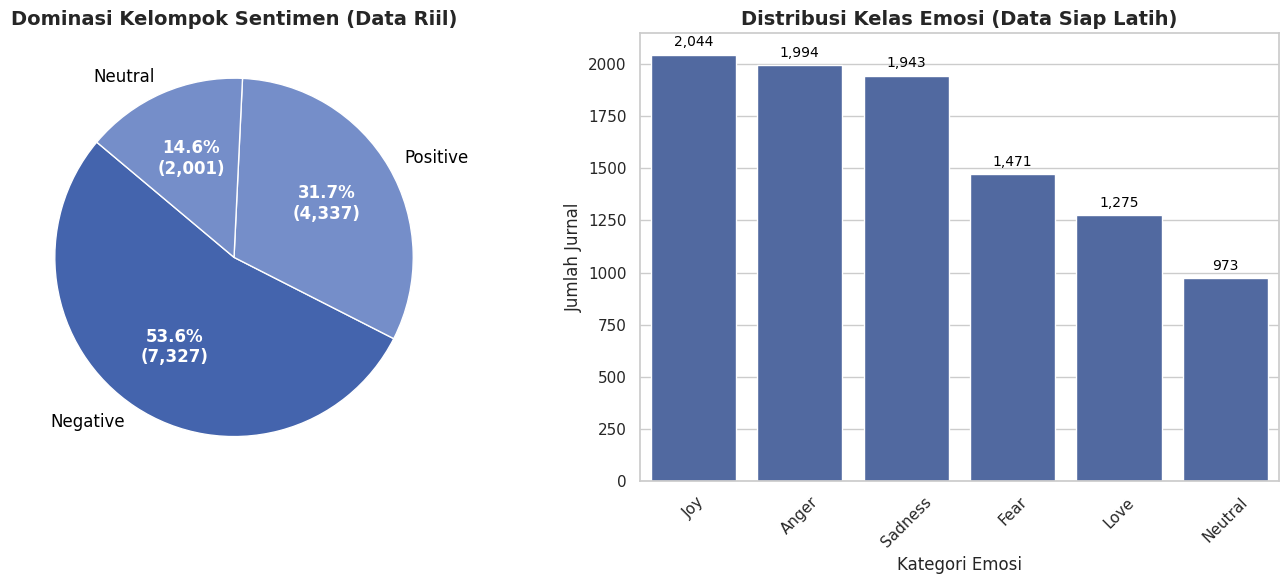

In [42]:
# Buat canvas dengan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define the corrected emotion map to match actual 'label_emosi' values
emotion_map_corrected = {
    'Sadness': 'Negative',
    'Anger': 'Negative',
    'Fear': 'Negative',
    'Joy': 'Positive',
    'Love': 'Positive',
    'Neutral': 'Neutral'
}

df_asli = df_combined.copy()

# Create 'emotion_group' for the "Data Riil" pie chart using df_asli
df_asli['emotion_group'] = df_asli['label_emosi'].map(emotion_map_corrected)

# Pie chart melihat dominasi kelompok sentimen (Data Riil)
group_counts = df_asli['emotion_group'].value_counts()

main_color = '#4464AD'
lighter_color = '#758EC9'

colors_for_pie = [main_color if label == group_counts.idxmax() else lighter_color for label in group_counts.index]

# Fungsi untuk menampilkan % dan jumlah asli
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return my_format

# Membuat pie chart
wedges, texts, autotexts = axes[0].pie(group_counts, labels=group_counts.index, autopct=autopct_format(group_counts.values),
            colors=colors_for_pie, startangle=140,
            textprops={'fontsize': 12})

# Mengubah color untuk labels (texts) menjadi hitam
for text in texts:
    text.set_color('black')

# Mengubah color untuk percentages (autotexts) menjadi putih
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('semibold')
    autotext.set_fontsize(12)

axes[0].set_title('Dominasi Kelompok Sentimen (Data Riil)', fontsize=14, fontweight='bold')

# Bar chart melihat kelas emosi yang siap latih (Setelah Balancing)
emotion_counts = df['label_emosi'].value_counts()
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, ax=axes[1], color='#4464AD', legend=False)

axes[1].set_title('Distribusi Kelas Emosi (Data Siap Latih)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kategori Emosi', fontsize=12)
axes[1].set_ylabel('Jumlah Jurnal', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Menambahkan anotasi angka di atas bar chart
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=10, fontweight='normal', color='black')

plt.tight_layout()
plt.show()

**Insight:**

- Berdasarkan visualisasi Pie Chart (kiri) pada data riil pengguna, sentimen didominasi secara signifikan oleh kelompok Negative sebesar 53.6% (7.327 entri). Kelompok ini merupakan gabungan dari emosi Anger, Sadness, dan Fear. Tingginya porsi sentimen negatif ini menegaskan bahwa sumber platform data lebih banyak difungsikan oleh pengguna sebagai ruang katarsis yang aman untuk menyalurkan keluh kesah dan tekanan mental mereka. Sentimen Positive (Joy dan Love) menyusul di angka 31.7% (4.337 entri), dan sentimen Neutral merupakan yang paling sedikit di angka 14.6% (2.001 entri).

- Pada Bar Chart (kanan), terlihat sebaran spesifik dari masing-masing kelas emosi pada data yang siap dilatih. Joy menjadi kelas individu terbanyak (2.044 entri), diikuti sangat ketat oleh Anger (1.994) dan Sadness (1.943), sementara Neutral menjadi kelas minoritas (973). Ketidakseimbangan (imbalance) komposisi ini tidak diubah dengan menyamaratakan jumlah baris (tanpa downsampling/oversampling), sehingga model tetap mendapatkan variasi data yang natural dan maksimal.

- Untuk mencegah bias prediksi pada arsitektur BiLSTM akibat distribusi data yang tidak merata tersebut, metode Global Class Weights (`class_weight='balanced'`) digunakan. Melalui dictionary bobot ini, model akan secara otomatis memberikan "perhatian" dan porsi bobot yang lebih besar pada kelas minoritas (seperti Neutral dan Love), serta menyeimbangkannya terhadap kelas mayoritas, sehingga pipeline pemodelan tetap objektif tanpa harus membuang data riil.

## Pertanyaan 2: Apakah terdapat perbedaan panjang teks (jumlah kata) antar kategori emosi, dan emosi mana yang cenderung menghasilkan curhatan lebih panjang?



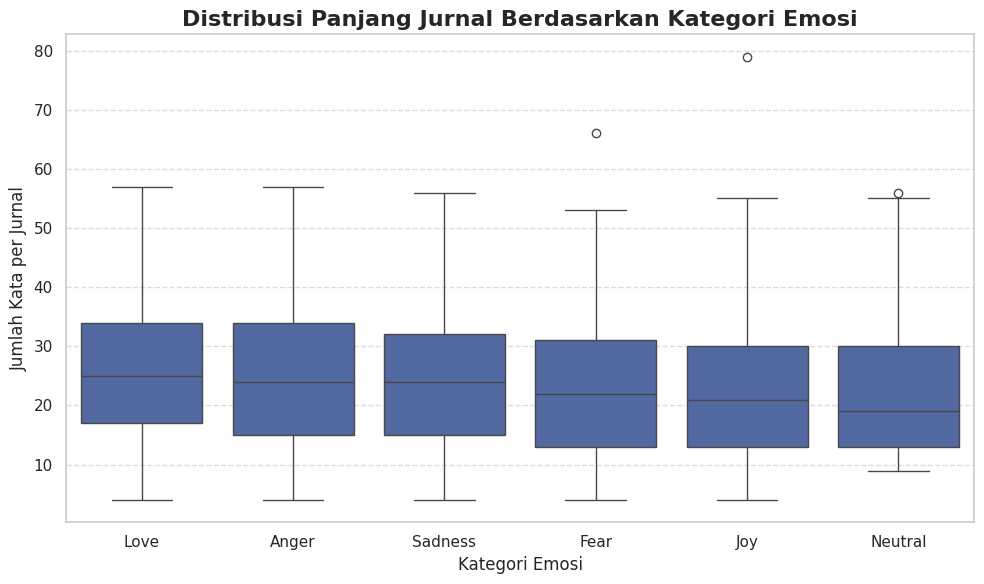

In [43]:
# Mengurutkan label emosi berdasarkan rata-rata jumlah kata dari tertinggi ke terendah
order_list = df_eda.groupby('label_emosi')['jumlah_kata'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))

# Menambahkan parameter 'order' agar urutan grafiknya rapi
sns.boxplot(x='label_emosi', y='jumlah_kata', data=df_eda, order=order_list,
            color='#4464AD')

plt.title('Distribusi Panjang Jurnal Berdasarkan Kategori Emosi', fontsize=16, fontweight='bold')
plt.xlabel('Kategori Emosi', fontsize=12)
plt.ylabel('Jumlah Kata per Jurnal', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Insight:**

- Menjawab pertanyaan bisnis, secara jelas terdapat perbedaan panjang teks antar kategori emosi. Setelah tahap penyesuaian dataset dan pemrosesan teks, pengguna rata-rata mengetik sebanyak 24 kata per jurnal.

- Emosi Love (Cinta) dan Anger (Marah) memicu pengguna untuk mengetik paling panjang, dengan rata-rata tertinggi masing-masing 25.55 kata dan 24.95 kata per entri jurnal. Hal ini menunjukkan fenomena psikologis di mana pengguna menjadi sangat ekspresif, detail, dan mendalam saat meluapkan perasaan kasih sayang yang kuat maupun rasa frustrasi mereka (keduanya memiliki sebaran panjang kata maksimal hingga 57 kata).

- Sebaliknya, emosi Neutral (Netral) menjadi kategori yang ditulis paling singkat dengan rata-rata 22.15 kata dan nilai tengah (median) terendah di angka 19 kata. Ini menegaskan kecenderungan pengguna untuk lebih to-the-point dan kasual saat tidak dikuasai oleh emosi yang intens. Meskipun Joy (Senang) memiliki rata-rata panjang teks (22.49 kata) yang lebih pendek dari Anger atau Sadness, emosi ini mencetak rekor outlier teks curhatan terpanjang secara absolut, yaitu mencapai 79 kata.

- Variasi panjang sekuens (sequence length) yang padat dan stabil di kisaran 20-an kata ini menjadi input yang sangat ideal bagi arsitektur BiLSTM. Model akan mendapatkan konteks kalimat yang utuh dan kaya untuk mempelajari pola serta menangkap makna relasi antar-kata, sehingga lebih optimal dalam membedakan luapan emosi intens (Love/Anger/Sadness) dengan pernyataan yang datar (Neutral).

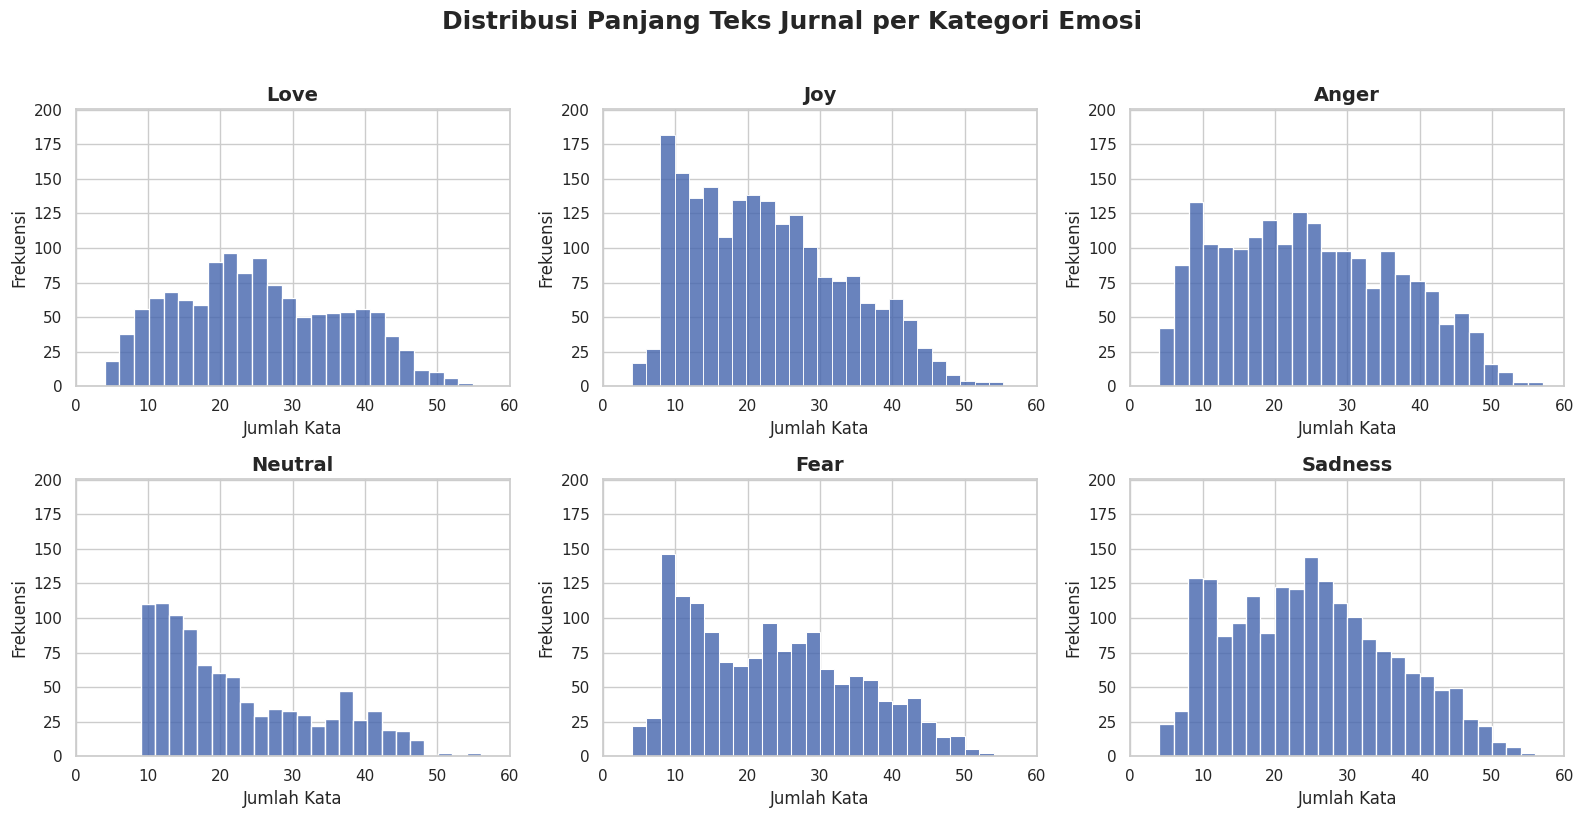

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

# Menentukan batas X yang masuk akal (memotong outlier ekstrem di atas 60 kata)
x_limit = 60

# Menentukan batas y-axis (frekuensi maksimum)
max_freq = 0
for emotion_label in emotion_labels:
    subset = df_eda[df_eda['label_emosi'] == emotion_label]['jumlah_kata']
    # Menghitung histogram counts untuk subset saat ini
    counts, _ = np.histogram(subset, bins=np.arange(0, x_limit + 2, 2)) # Menggunakan x_limit untuk consistent binning
    if len(counts) > 0:
        current_max_freq = counts.max()
        if current_max_freq > max_freq:
            max_freq = current_max_freq

# Menyesuaikan max_freq
max_freq_padded = max_freq * 1.1

for i, emotion_label in enumerate(emotion_labels):
    subset = df_eda[df_eda['label_emosi'] == emotion_label]['jumlah_kata']

    # binwidth=2 agar lebar batangnya seragam
    sns.histplot(subset, binwidth=2, alpha=0.8, color='#4464AD', ax=axes[i], edgecolor='white')

    axes[i].set_title(f'{emotion_label.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_xlim(0, x_limit)
    axes[i].set_ylim(0, max_freq_padded)

    axes[i].set_xlabel('Jumlah Kata', fontsize=12)
    axes[i].set_ylabel('Frekuensi', fontsize=12)

plt.suptitle('Distribusi Panjang Teks Jurnal per Kategori Emosi', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:**

- Melengkapi analisis Boxplot, visualisasi KDE Plot (Histogram) ini memperlihatkan bentuk sebaran kepadatan data (density) secara lebih granular. Terlihat jelas bahwa distribusi panjang teks membentuk kurva yang memusat di kisaran 15 hingga 35 kata untuk hampir semua kategori emosi.

- Pada emosi Joy (Senang), terlihat ekor grafik yang menjulur paling jauh ke kanan hingga mendekati angka 80 kata, yang secara visual sebagai rekor teks terpanjang (outlier). Untuk emosi dengan intensitas tinggi lainnya seperti Anger, Love, dan Sadness, sebarannya tampak padat dan stabil dengan ekor yang berakhir di kisaran 60 kata.

- Perbedaan pola paling terlihat pada grafik Neutral. Puncak kepadatannya (peak) bergeser sedikit lebih ke kiri dibandingkan emosi lain, dan kurvanya menukik turun lebih cepat tanpa ekor yang panjang. Ini memvisualisasikan dengan sangat jelas bahwa hampir tidak ada pengguna yang bertele-tele atau mengetik panjang lebar ketika suasana hati mereka sedang datar.

- Distribusi data yang rapi dan terpusat menyerupai kurva normal ini sangat menguntungkan tahap preprocessing. Tim AI dapat menentukan parameter max_length (misalnya di angka 45 atau 50) saat proses tokenisasi. Dengan sebaran seperti ini, model tidak akan banyak membuang konteks kalimat karena pemotongan (truncation), sekaligus meminimalisir penambahan nol (padding) yang berlebihan pada sekuens BiLSTM.

## Pertanyaan 3: Kata-kata apa yang paling sering muncul pada emosi (sad, angry, fearful, happy, neutral, disgusted), dan tema apa yang paling dominan dalam curhatan pengguna?



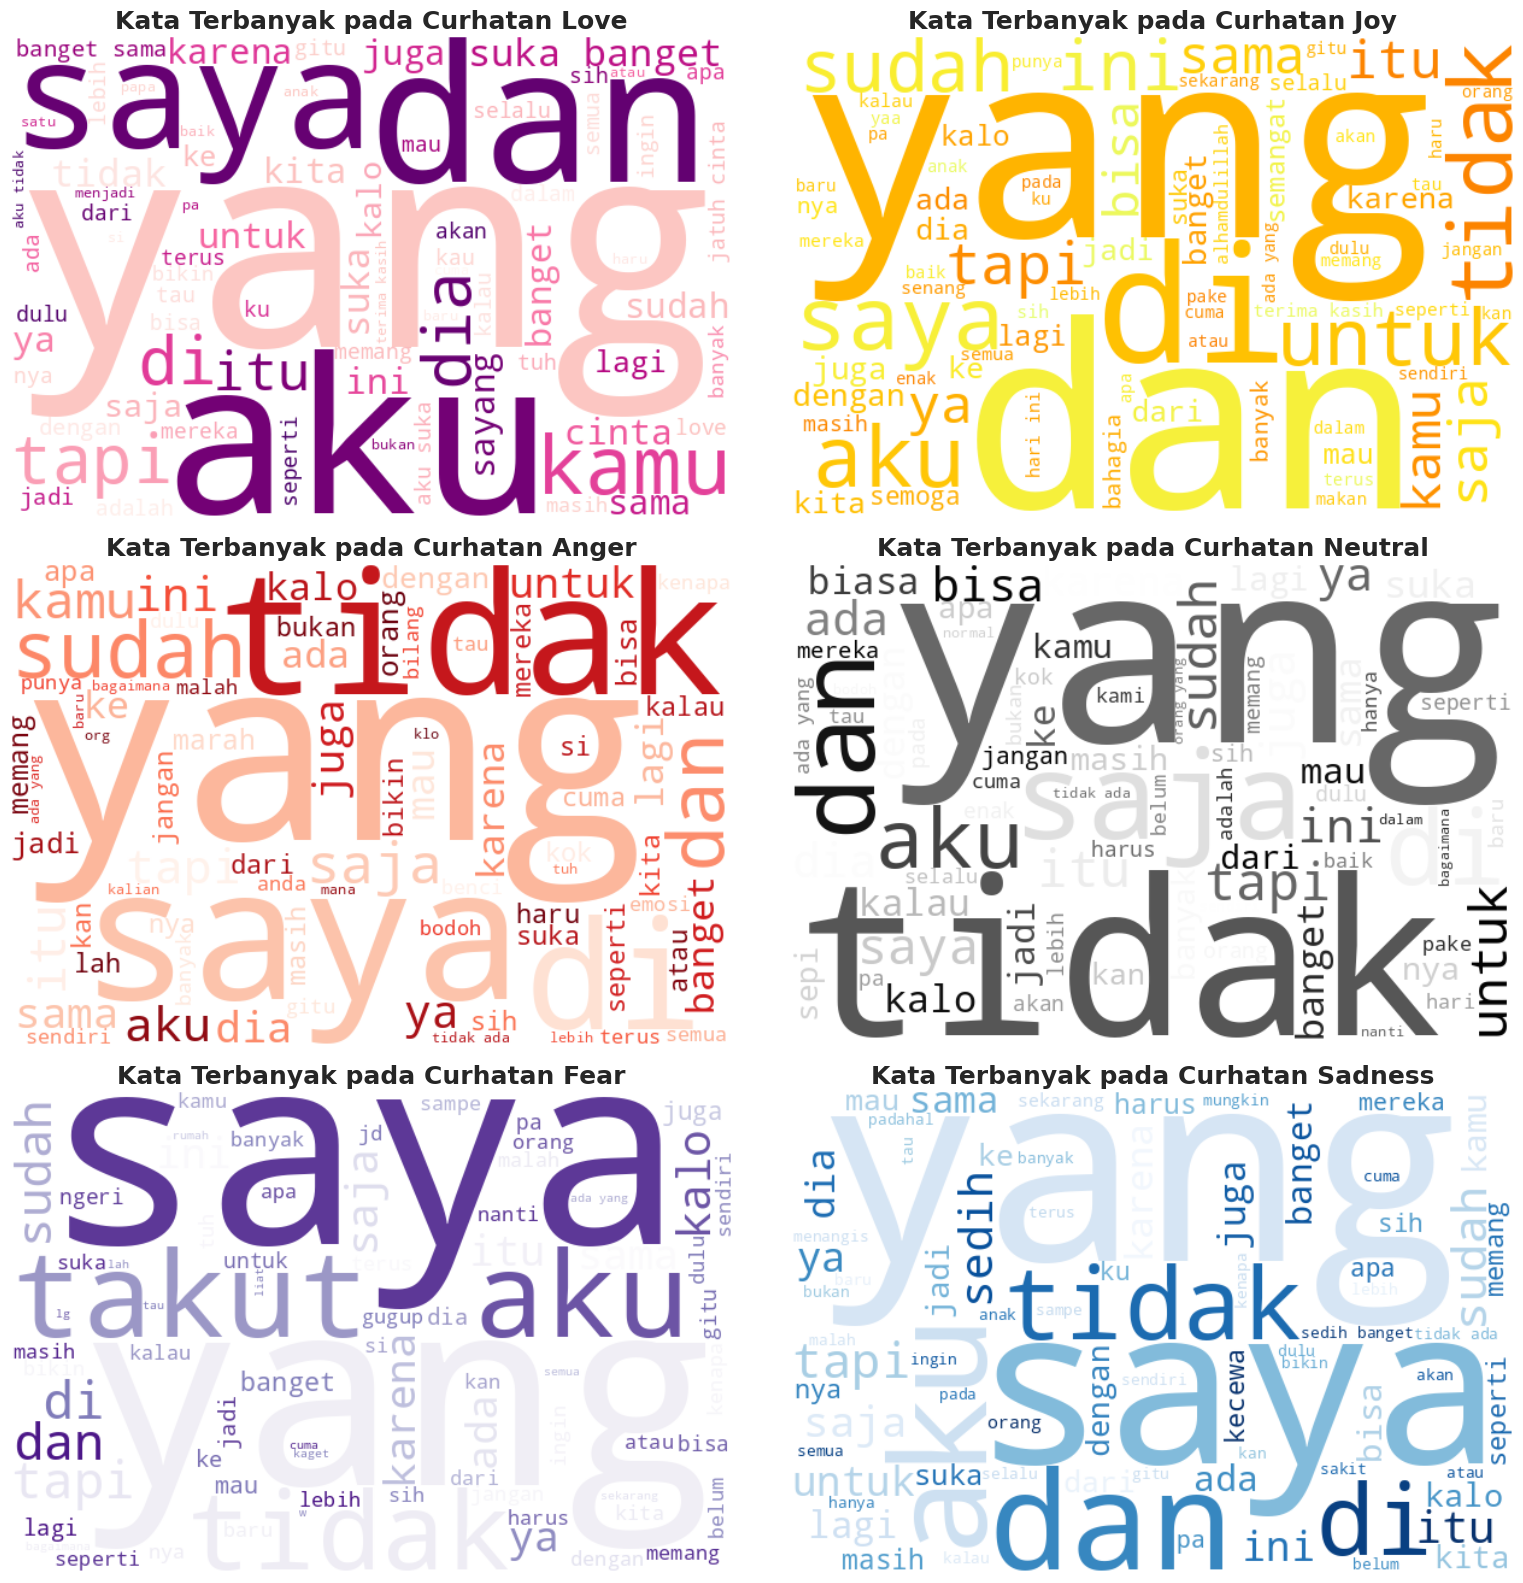

In [45]:
# Mendefinisikan palet warna yang merepresentasikan secara psikologis
colormap_dict = {
    'Joy': 'Wistia',     # Kuning-oranye (cerah/positif)
    'Sadness': 'Blues',        # Biru (sendu)
    'Anger': 'Reds',       # Merah (agresif/marah)
    'Fear': 'Purples',  # Ungu (cemas/takut)
    'Love': 'RdPu', # Merah ungu (cinta/sayang)
    'Neutral': 'Greys'     # Abu-abu (netral/objektif)
}

# Membuat kanvas 2 baris, 3 kolom
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, emotion_label in enumerate(emotion_labels):
    # Menggabungkan semua teks untuk emosi tersebut
    subset_text = ' '.join(df[df['label_emosi'] == emotion_label]['text_clean'])

    # Generate WordCloud dengan maksimal 75 kata
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colormap_dict.get(emotion_label, 'viridis'),
        max_words=75
    ).generate(subset_text)

    # Menampilkan ke dalam subplot
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Kata Terbanyak pada Curhatan {emotion_label.capitalize()}", fontsize=18, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan ekstraksi 75 kata terbanyak dari masing-masing kategori emosi dan visualisasi WordCloud, dapat dilihat bahwa daftar teratas secara konsisten didominasi oleh kata hubung, negasi, dan kata ganti subjek ("yang", "tidak", "saya", "aku", "di", "dan"). Sesuai dengan desain rekayasa data, kata-kata ini sengaja dipertahankan karena model BiLSTM membutuhkannya sebagai jangkar untuk memahami struktur dan arah emosi secara sekuensial.

Namun, di luar kata-kata umum tersebut, masing-masing emosi memancarkan tema dan leksikon (kosakata) unik yang sangat representatif:

- Anger (Marah): Tema Konfrontasi dan Frustrasi

  Emosi ini sangat reaktif terhadap pihak luar. Di luar kata eksplisit seperti "marah" (217), "benci" (175), dan "kesal" (79), curhatan ini dipenuhi oleh subjek pihak kedua dan ketiga ("kamu", "orang", "dia", "mereka", "anda"). Munculnya kata "bikin", "salah", dan "bodoh" mempertegas tema *blaming* (menyalahkan) atau kekesalan terhadap pemicu eksternal.
  
- Fear (Takut): Tema Kecemasan dan Keterkejutan

  Kategori ini memiliki spektrum kosakata respons psikis dan fisik yang sangat kaya, seperti "takut" (718), "ngeri" (169), "gugup" (72), "serem" (67), "malu" (66), hingga "kaget" (65). Kehadiran kata situasi seperti "pas", "liat", dan "nanti" menunjukkan bahwa ketakutan pengguna sering dipicu oleh antisipasi akan suatu kejadian (kecemasan masa depan) atau respons atas peristiwa mendadak.

- Love (Cinta): Tema Afeksi dan Kedekatan Personal

  Didominasi secara absolut oleh kata afeksi seperti "suka" (702), "sayang" (418), dan "cinta" (392). Tema interaksi yang intim sangat terasa dengan tingginya frekuensi pasangan kata "aku" dan "kamu", serta keberadaan kata pendukung seperti "jatuh" (merujuk pada jatuh cinta), "hati", dan "selalu".

- Joy (Senang): Tema Rasa Syukur dan Harapan Positif

  Berbeda dengan emosi lain, *Joy* sangat kental dengan nuansa religiusitas, rasa syukur, dan optimisme. Hal ini dibuktikan dengan kemunculan kata "semangat", "semoga", "bahagia", "alhamdulillah", "sehat", "bangga", hingga "allah". Curhatan pada kelas ini sering kali menceritakan keberhasilan atau apresiasi terhadap hari yang baik.

- Sadness (Sedih): Tema Kekecewaan dan Kesepian Internal

  Kesedihan dimanifestasikan melalui rasa sakit yang terinternalisasi. Di samping kata "sedih" (527), tema curhatan ini diperjelas oleh kata "kecewa" (153), "menangis" (94), "sakit" (91), dan "sendiri" (109). Tingginya penggunaan kata "tapi" (514) juga menjadi pola sintaksis klasik untuk keluhan tentang realita yang tidak seindah harapan.

- Neutral (Netral): Tema Rutinitas Objektif
  
  Leksikon pada kelas ini mengonfirmasi sifatnya yang datar. Kata-kata yang mencuat adalah "biasa" (182), "saja" (394), "normal" (45), dan "kabar" (45). Narasi pengguna di sini murni bersifat deskriptif mengenai keseharian tanpa adanya muatan sentimen yang meledak-ledak.


Ke-75 kosakata teratas ini membuktikan bahwa meskipun dataset didominasi oleh kata hubung, setiap kelas emosi tetap memiliki *fingerprint* tema yang sangat kuat. Variasi kata spesifik ini yang akan dipelajari oleh model AI untuk melakukan klasifikasi sentimen secara akurat.

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9700 entries, 0 to 10237
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   journal_id     9700 non-null   object        
 1   user_id        9700 non-null   int64         
 2   text_jurnal    9700 non-null   object        
 3   text_clean     9700 non-null   object        
 4   timestamp      9700 non-null   datetime64[ns]
 5   label_emosi    9700 non-null   object        
 6   label_encoded  9700 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 606.2+ KB


In [47]:
df.head()

,journal_id,user_id,text_jurnal,text_clean,timestamp,label_emosi,label_encoded
0,4edace48,1,"iya, mau kelarin! suka banget sama adaptasinya...",iya mau kelarin suka banget sama adaptasinya k...,2026-02-08 03:56:37.068236,Love,3
1,ece82cd6,623,"kita mungkin sekarang merasa takut, tapi nanti...",kita mungkin sekarang merasa takut tapi nanti ...,2026-02-08 04:09:36.068236,Joy,2
2,a2a3d3ae,546,Bisa mencium bau tanah kering yang abis kesira...,bisa mencium bau tanah kering yang abis kesira...,2026-02-08 04:29:14.068236,Joy,2
3,759bdfd0,528,itu knp gue benci bgt. mrk yg enak kita yg sen...,itu kenapa saya benci banget mrk yang enak kit...,2026-02-08 04:38:42.068236,Anger,0
5,cdb3a41a,897,dulu gue pernah diajarin buat cari tau apa yan...,dulu saya pernah diajarin untuk cari tau apa y...,2026-02-08 04:55:01.068236,Neutral,4


# Conclusion

- Conclusion Pertanyaan 1 (Distribusi & Dominasi Emosi)

  Berdasarkan analisis data riil, pengguna secara signifikan mendominasi platform dengan sentimen Negative (53.6%), menjadikan platform ini sebagai ruang katarsis untuk menyalurkan tekanan mental (gabungan Anger, Sadness, Fear). Pada tahap penyiapan data latih, ketidakseimbangan kelas (imbalance), dengan Joy sebagai mayoritas (2.044 entri) dan Neutral sebagai minoritas (973 entri), sengaja dipertahankan tanpa resampling agar variasi data tetap natural. Sebagai solusi pemodelan, pendekatan Global Class Weights diterapkan pada arsitektur BiLSTM. Metode ini memastikan model memberikan bobot perhatian yang seimbang pada kelas minoritas, sehingga prediksi tetap objektif tanpa harus mengorbankan integritas data asli.

- Conclusion Pertanyaan 2 (Analisis Panjang Teks)

  Hasil analisis struktural teks mengungkapkan korelasi kuat antara intensitas emosi dan panjang penjabaran pengguna (rata-rata 24 kata per jurnal). Pengguna terbukti paling ekspresif saat meluapkan emosi Love dan Anger (rata-rata ~25 kata), dan sebaliknya, paling ringkas pada emosi Neutral (rata-rata ~22 kata). Distribusi kepadatan teks secara keseluruhan membentuk kurva normal yang terpusat di kisaran 15-35 kata. Karakteristik sebaran yang rapi ini sangat ideal bagi preprocessing model BiLSTM, karena memungkinkan penetapan parameter max_length yang optimal (misal di angka 45-50) untuk meminimalisir pemotongan konteks (truncation) sekaligus menghindari penambahan nol (padding) yang berlebihan pada sekuens.

- Conclusion Pertanyaan 3 (Leksikon & Tema Dominan)
  
  Analisis frekuensi dan WordCloud membuktikan bahwa meskipun kata hubung dan kata ganti dipertahankan (sebagai jangkar konteks sekuensial bagi BiLSTM), keenam kelas emosi memiliki fingerprint leksikon yang sangat distingtif. Anger berpusat pada konfrontasi eksternal, Fear pada kecemasan antisipatif, Love pada kedekatan personal, Joy kental dengan rasa syukur, Sadness bermanifestasi pada kekecewaan internal, dan Neutral murni berisi deskripsi rutinitas yang objektif. Keunikan klaster kosakata ini mengonfirmasi bahwa data yang digunakan memiliki batas antar-kelas yang tajam, sehingga akan sangat memudahkan algoritma AI dalam mengklasifikasikan sentimen pengguna secara akurat.

# Feature Engineering (Notes)

---

# 🏗️ Feature Engineering Decision Log

&gt; **Catatan untuk Tim Reviewer Dicoding & AI Engineer**

## Pendekatan yang Digunakan

Dalam pipeline data preparation ini, **fitur-fitur yang dihasilkan selama proses cleaning sengaja TIDAK dipertahankan** dalam dataset final yang diekspor. Berikut reasoning dan konteks keputusannya:

---

## 📋 Fitur-Fitur yang Dibuat Selama Pipeline (Tapi Dibuang)

| Fitur | Fungsi dalam Pipeline | Mengapa Dibuang |
|:---|:---|:---|
| `word_count` | Filter POV & panjang minimum teks | Hanya untuk threshold filtering, bukan prediktor emosi |
| `is_personal` | Deteksi kata ganti orang pertama | Hanya untuk filter journaling context, bukan fitur model |
| `english_count` | Deteksi code-switching berat | Hanya untuk eliminasi data noise, bukan fitur prediktif |
| `jumlah_kata` | Analisis EDA panjang teks | Hanya untuk insight statistik, bukan input model |
---

## 🤝 Separation of Concerns: Data Scientist vs AI Engineer

Berdasarkan **Project Plan CC26-PSU309** dan pembagian tugas learning path:

### ✅ Tugas Data Scientist (Notebook Ini)
- **Data Wrangling**: Gathering, assessing, cleaning
- **Data Quality**: Menjamin integritas, konsistensi, dan kelayakan data
- **Feature Engineering Dasar**: Encoding label (`label_encoded`) dan metadata struktural
- **Explanatory Analysis**: Insight bisnis untuk stakeholder
- **Dashboard Analitik**: Visualisasi tren dan pola

### 🔧 Tugas AI Engineer (Tim Terpisah)
- **Feature Engineering Model-Specific**: TF-IDF, word embeddings, attention weights, dll
- **Model Architecture**: BiLSTM, attention layers, regularization
- **Hyperparameter Tuning**: Dropout, learning rate, batch size
- **Train/Val/Test Split**: Stratified split dengan random seed
- **Model Evaluation**: Accuracy, precision, recall, F1-score

&gt; **Prinsip**: Data Scientist menyediakan **data bersih dan well-documented**, AI Engineer menentukan **fitur optimal untuk arsitektur spesifik** mereka.

---

## 🧠 Mengapa Fitur Linguistik Tidak Dipertahankan?

Beberapa pertimbangan teknis:

### 1. **BiLSTM Membutuhkan Input Teks Mentah**
Arsitektur BiLSTM yang akan dibangun AI Engineer menggunakan:
- **Embedding Layer**: Mengubah token teks menjadi vektor dense
- **Bidirectional LSTM**: Memproses sequence forward + backward
- **Attention Mechanism**: Fokus pada kata-kata penting dalam konteks

Fitur manual seperti `word_count` atau `char_count` bisa **mengganggu** learning representation dari embedding layer.

### 2. **Risk of Data Leakage**
Jika fitur statistik (panjang teks, jumlah tanda baca) dipertahankan:
- Model bisa "curang" dengan memprediksi emosi berdasarkan **format** tulisan, bukan **konten** semantik
- Contoh: "Teks panjang = Love", ini bias yang tidak diinginkan

### 3. **Flexibilitas untuk AI Engineer**
Dengan menyediakan **hanya teks bersih + label**, AI Engineer bebas untuk:
- Mencoba berbagai tokenizer (WordPiece, BPE, SentencePiece)
- Menggunakan pretrained embeddings (Word2Vec, FastText, IndoBERT)
- Menerapkan data augmentation (back-translation, synonym replacement)
- Menentukan sequence length optimal berdasarkan eksperimen

---

## 🔮 Rekomendasi Fitur untuk AI Engineer (Opsional)

Jika AI Engineer membutuhkan fitur tambahan, berikut **rekomendasi** yang bisa diekstrak dari `text_clean`:

```python
# Contoh fitur yang bisa ditambahkan oleh AI Engineer:

# 1. TF-IDF / Bag-of-Words (untuk baseline comparison)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)

# 2. Word Embeddings (pre-trained)
# - Word2Vec Bahasa Indonesia
# - FastText
# - IndoBERT embeddings

# 3. Fitur Linguistik Tambahan (jika diperlukan)
df['char_count'] = df['text_clean'].str.len()
df['word_count'] = df['text_clean'].str.split().str.len()
df['avg_word_length'] = df['text_clean'].apply(lambda x: np.mean([len(w) for w in x.split()]))

# 4. Temporal Features (untuk time-series analysis)
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)

# 5. Sentiment Polarity (sebagai fitur tambahan)
# Menggunakan library seperti TextBlob, VADER, atau IndoNLU

# Finalisasi & Export Data

### Data Dictionary Final

Tabel ini menjelaskan setiap fitur (kolom) yang terdapat pada dataset akhir setelah proses pembersihan data (Data Cleaning) dan feature engineering. Dataset ini siap digunakan untuk pemodelan sentimen emosi.

| Nama Kolom | Tipe Data | Kategori | Deskripsi |
| :--- | :--- | :--- | :--- |
| `journal_id` | String / Object | Identifier | Kode unik untuk mengidentifikasi setiap entri jurnal atau teks curhatan. |
| `user_id` | Integer | Identifier | Nomor unik pengguna yang menulis jurnal tersebut. |
| `text_jurnal` | String / Object | Fitur Utama | Teks curhatan yang belum melalui tahap *preprocessing*. |
| `text_clean` | String / Object | Fitur Utama | Teks curhatan yang sudah melalui tahap *preprocessing* (seperti *case folding*, penghapusan tanda baca, dan *stopword* removal) sehingga siap diproses oleh model. |
| `timestamp` | Datetime | Waktu | Waktu dan tanggal saat jurnal atau curhatan tersebut direkam. |
| `label_emosi` | String / Object | Target | Label apakah teks mengandung emosi marah, senang, takut, sayang, netral, atau sedih (6 kelas). |
| `label_encoded` | Integer | Target | Label emosi dalam bentuk angka (0-5). |

## Export Data

In [49]:
df.to_csv('dataset_ruangrasa_jurnal_ai.csv', index=False)